In [ ]:
#Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Conv2D,
    AveragePooling2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import Dropout

In [ ]:
#Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training Shape  :", x_train.shape)
print("Validation Shape:", x_val.shape)
print("Test Shape      :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2956s 17us/step
Training Shape  : (40000, 32, 32, 3)
Validation Shape: (10000, 32, 32, 3)
Test Shape      : (10000, 32, 32, 3)


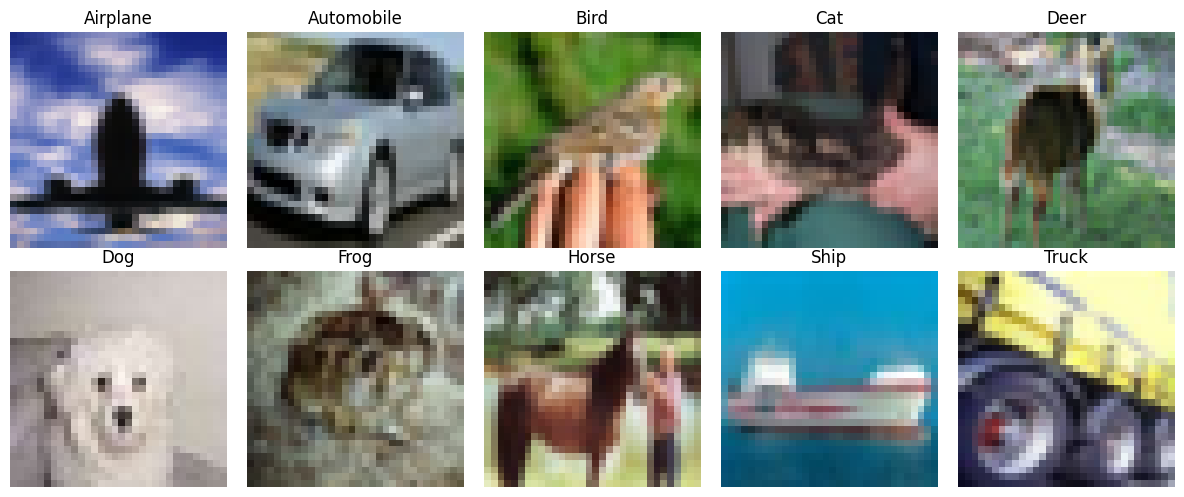

In [ ]:
#Visualize the dataset
class_names = [
    'Airplane','Automobile','Bird','Cat','Deer',
    'Dog','Frog','Horse','Ship','Truck'
    ]

plt.figure(figsize=(12,5))

for class_id in range(10):

    idx = np.where(y_train.flatten() == class_id)[0][0]

    plt.subplot(2,5,class_id+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
#One-Hot Encoding
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
#Augmentation
datagen_model = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True
)

datagen_model.fit(x_train)

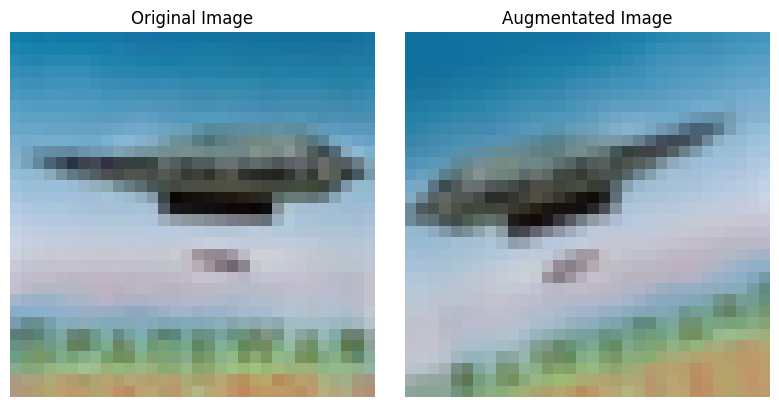

In [ ]:
#Show and Compare Augmented images of Model A & B with Orginal images
sample = np.expand_dims(x_train[365], axis=0)

aug_model = datagen_model.flow(sample, batch_size=1)

img_A = next(aug_model)[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(x_train[365])
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_A)
plt.title("Augmentated Image")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Build Model
def build_model():

    model = Sequential()

    model.add(
        Conv2D(
            6,
            (5,5),
            activation='tanh',
            input_shape=(32,32,3)
        )
    )

    model.add(
        AveragePooling2D(pool_size=(2,2))
    )

    model.add(
        Conv2D(
            16,
            (5,5),
            activation='tanh'
        )
    )

    model.add(
        AveragePooling2D(pool_size=(2,2))
    )

    model.add(Flatten())

    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

In [ ]:
model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

In [ ]:
history_model = model.fit(
    datagen_model.flow(
        x_train,
        y_train,
        batch_size=64
    ),
    epochs=50,
    validation_data=(x_test,y_test),
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.3478 - loss: 1.8393 - val_accuracy: 0.3881 - val_loss: 1.7260 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4121 - loss: 1.6560 - val_accuracy: 0.4325 - val_loss: 1.6019 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4577 - loss: 1.5176 - val_accuracy: 0.4834 - val_loss: 1.4564 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4897 - loss: 1.4280 - val_accuracy: 0.4928 - val_loss: 1.4266 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.5156 - loss: 1.3649 - val_accuracy: 0.5201 - val_loss: 1.3497 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5274 - loss: 1.3227 - val_accuracy: 0.5339 - val_loss: 1.3109 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.5423 - l

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


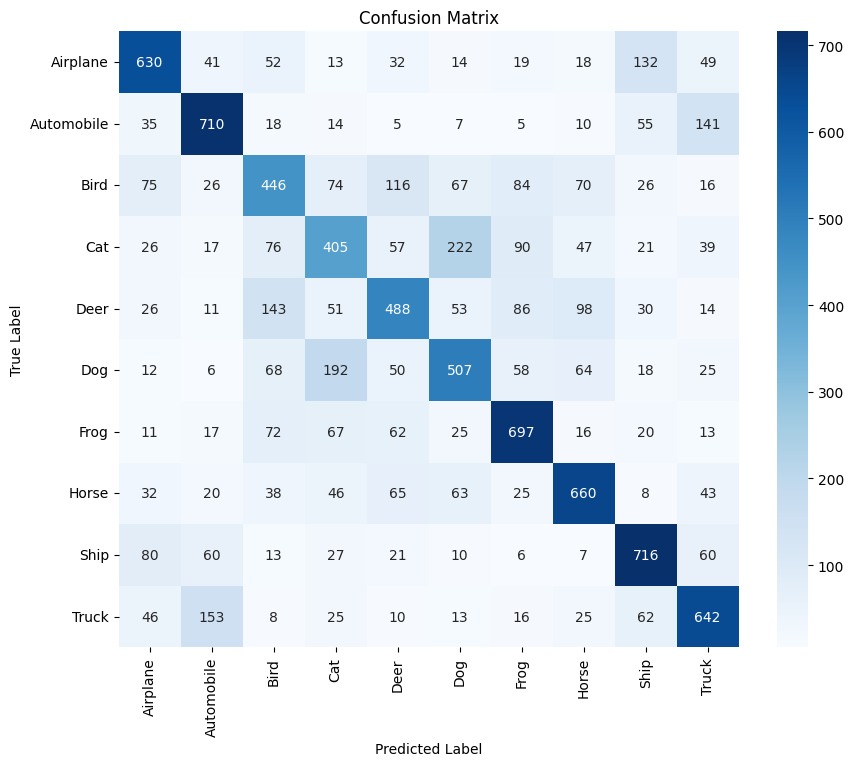

In [ ]:
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

cm_test = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

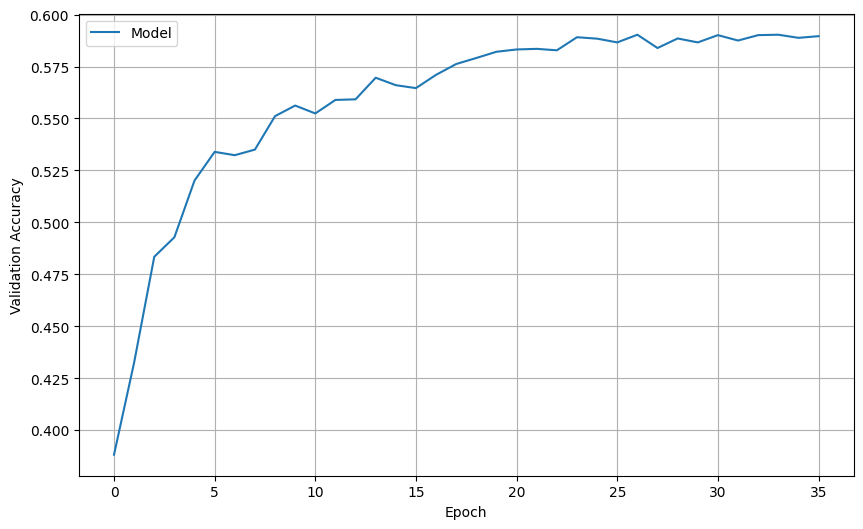

In [ ]:
#Accuracy Comparison Graph
plt.figure(figsize=(10,6))

plt.plot(
    history_model.history['val_accuracy'],
    label='Model'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

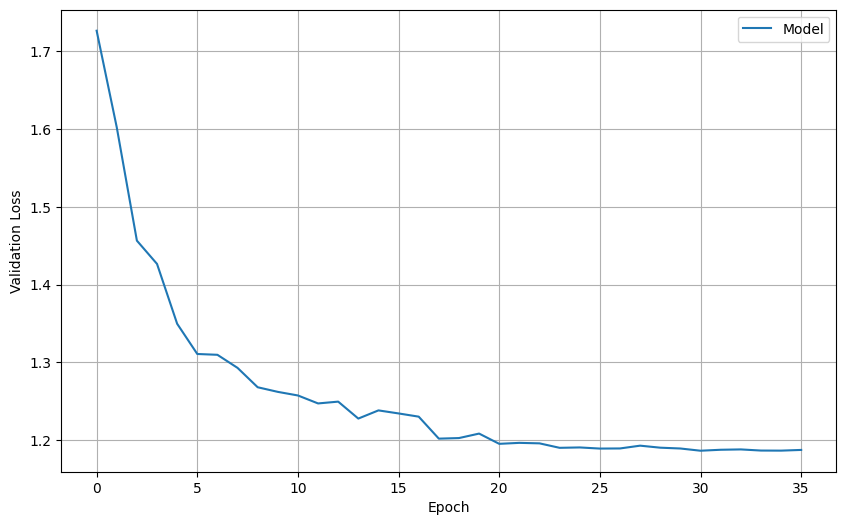

In [ ]:
#Loss Comparison Graph
plt.figure(figsize=(10,6))

plt.plot(
    history_model.history['val_loss'],
    label='Model'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
df_model = pd.DataFrame({
    'Epoch': range(1, len(history_model.history['accuracy']) + 1),
    'Accuracy': history_model.history['accuracy'],
    'Validation Accuracy': history_model.history['val_accuracy'],
    'Loss': history_model.history['loss'],
    'Validation Loss': history_model.history['val_loss']
})

print("=======================================================================")
print("\t\t\t\t\tAccuracy Table for the Model")
print("=======================================================================")

df_model

					Accuracy Table for the Model


,Epoch,Accuracy,Validation Accuracy,Loss,Validation Loss
0,1,0.347800,0.3881,1.839324,1.725990
1,2,0.412050,0.4325,1.656008,1.601948
2,3,0.457650,0.4834,1.517568,1.456443
3,4,0.489700,0.4928,1.428008,1.426554
4,5,0.515550,0.5201,1.364899,1.349740
5,6,0.527400,0.5339,1.322704,1.310910
6,7,0.542300,0.5323,1.284118,1.309870
7,8,0.550725,0.5350,1.262295,1.293074
8,9,0.560325,0.5511,1.232104,1.268201
9,10,0.565675,0.5562,1.215997,1.262270


In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Total Epochs',
        'Final Training Accuracy',
        'Best Validation Accuracy',
        'Final Validation Accuracy',
        'Final Training Loss',
        'Best Validation Loss',
        'Final Validation Loss'
    ],
    'Value': [
        len(history_model.history['accuracy']),
        f"{history_model.history['accuracy'][-1]*100:.2f}%",
        f"{max(history_model.history['val_accuracy'])*100:.2f}%",
        f"{history_model.history['val_accuracy'][-1]*100:.2f}%",
        round(history_model.history['loss'][-1], 4),
        round(min(history_model.history['val_loss']), 4),
        round(history_model.history['val_loss'][-1], 4)
    ]
})

display(summary)

,Metric,Value
0,Total Epochs,36
1,Final Training Accuracy,66.31%
2,Best Validation Accuracy,59.03%
3,Final Validation Accuracy,58.96%
4,Final Training Loss,0.9601
5,Best Validation Loss,1.1867
6,Final Validation Loss,1.1877
